## 📊 Data Analytics Project: **Loan Risk Analysis**



In [ ]:
# Import the libraries
#import piplite
#await piplite.install('seaborn')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
%matplotlib inline


In [ ]:
# Load the Dataset in pandas
df = pd.read_csv('Loan_Default.csv')

# Show me all columns in the ouput
desired_width=320
pd.set_option('display.width', desired_width)
pd.set_option('display.max_columns', None)

# Let's see the basic info about our dataset
# (rows, columns)
df.shape


(148670, 36)

In [ ]:
# Types of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   date of the loan           148670 non-null  object 
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [ ]:
# First 5 rows of the dataset
df.head()

,ID,date of the loan,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1,month,quarter
0,24890,5/1/2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0,5,2
1,24891,12/1/2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN,12,4
2,24892,9/1/2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0,9,3
3,24893,7/1/2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0,7,3
4,24894,3/1/2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.0,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0,3,1


In [ ]:
# STANDARDIZE COLUMN NAMES

# Before doing anything, we fix all column names so they are:
#   - all lowercase
#   - spaces replaced with underscores
# This avoids case mismatch errors later in the code.

df.columns = (df.columns
              .str.strip()           # remove extra spaces
              .str.lower()           # make everything lowercase
              .str.replace(" ", "_")
              .str.replace("-", "_")) # replace spaces with underscores

print("Cleaned column names:")
print(df.columns.tolist())
print()

Cleaned column names:
['id', 'date_of_the_loan', 'loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'credit_worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'interest_rate_spread', 'upfront_charges', 'term', 'neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'secured_by', 'total_units', 'income', 'credit_type', 'credit_score', 'co_applicant_credit_type', 'age', 'submission_of_application', 'ltv', 'region', 'security_type', 'status', 'dtir1', 'month', 'quarter']



In [ ]:
# Handle Missing Values

# First, let's SEE which columns have missing values and how many
#creates a header
print("=" * 50)
print(" Missing Values")
print("=" * 50)

# checks every single cell and returns True if it's empty, False if it has a value
# counts all the true values per column
print(df.isnull().sum())
print()

 Missing Values
id                               0
date_of_the_loan                 0
loan_limit                    3344
gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
credit_worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
interest_rate_spread         36639
upfront_charges              39642
term                            41
neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
secured_by                       0
total_units                      0
income                        9150
credit_type                      0
credit_score                     0
co_applicant_credit_type         0
age                            200
subm

In [ ]:
# SEE THE PERCENTAGE OF MISSING VALUES

# WHAT PERCENTAGE of the column is missing.
print("=" * 50)
print(" Missing Values (%)")
print("=" * 50)

# len(df)   total number of rows
# * 100     convert to percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

# round(2)  show only 2 decimal places
print(missing_percent.round(2))
print()

 Missing Values (%)
id                            0.00
date_of_the_loan              0.00
loan_limit                    2.25
gender                        0.00
approv_in_adv                 0.61
loan_type                     0.00
loan_purpose                  0.09
credit_worthiness             0.00
open_credit                   0.00
business_or_commercial        0.00
loan_amount                   0.00
rate_of_interest             24.51
interest_rate_spread         24.64
upfront_charges              26.66
term                          0.03
neg_ammortization             0.08
interest_only                 0.00
lump_sum_payment              0.00
property_value               10.16
construction_type             0.00
occupancy_type                0.00
secured_by                    0.00
total_units                   0.00
income                        6.15
credit_type                   0.00
credit_score                  0.00
co_applicant_credit_type      0.00
age                           0.13


In [ ]:

# SHOW ONLY COLUMNS THAT HAVE MISSING VALUES

# Filtering the columns that actually have missing values.
print("=" * 50)
print(" Columns WITH Missing Values Only")
print("=" * 50)

# missing_percent > 0   keeps only columns where missing % is above 0
cols_with_missing = missing_percent[missing_percent > 0]

if len(cols_with_missing) == 0:
    print("No missing values found.")
else:
    print(cols_with_missing.round(2))
print()

 Columns WITH Missing Values Only
loan_limit                    2.25
approv_in_adv                 0.61
loan_purpose                  0.09
rate_of_interest             24.51
interest_rate_spread         24.64
upfront_charges              26.66
term                          0.03
neg_ammortization             0.08
property_value               10.16
income                        6.15
age                           0.13
submission_of_application     0.13
ltv                          10.16
dtir1                        16.22
dtype: float64



In [ ]:
# NORMALIZED THE DATA: FILL IN MISSING VALUES — NUMBER COLUMNS WITH MEDIAN

# We use median instead of average (mean) because:
#   Average is affected by very large or very small numbers
#   Median stays closer to the "typical" value

numeric_cols_to_fill = [
    "rate_of_interest",     # annual interest rate
    "interest_rate_spread", # difference from benchmark rate
    "upfront_charges",      # fees paid at loan start
    "term",                 # loan duration in months
    "property_value",       # estimated property value
    "income",               # applicant's income
    "ltv",                  # loan-to-value ratio
    "dtir1"                 # debt-to-income ratio
]

# Fill all empty cells with the median in one line
df[numeric_cols_to_fill] = df[numeric_cols_to_fill].fillna(df[numeric_cols_to_fill].median())   # The inner part calculates the median for each column separately.
                                                                                                # the outer part Fills every empty cell with the median value of that column.
# Confirm and grabs only the numeric columns we just filled
print("Missing values after filling:")                                                          # .isnull() Marks every empty cell as True, filled cell as False
print(df[numeric_cols_to_fill].isnull().sum())                                                  # .sum()Counts all the True values per column
print()

Missing values after filling:
rate_of_interest        0
interest_rate_spread    0
upfront_charges         0
term                    0
property_value          0
income                  0
ltv                     0
dtir1                   0
dtype: int64



In [ ]:

# NORMALIZED THE DATA: DROP ROWS WITH MISSING CATEGORICAL VALUES
# These are the TEXT columns in our dataset

#Shows teh rows before dropping
rows_before = len(df)

# Drop rows where any of these columns have an empty cell                         # df.dropna() Removes rows that have empty cells
df = df.dropna(subset=[                                                           # subset=[...] Only checks these specific columns for empty cells
    "loan_limit",               # conforming or non-conforming loan
    "approv_in_adv",            # was the loan pre-approved?
    "loan_purpose",             # buy, refinance, or build?
    "neg_ammortization",        # does the debt grow over time?
    "age",                      # age group of the applicant
    "submission_of_application",# applied directly or through a broker?
])

rows_after  = len(df)                                                             # How many rows are left after dropping
rows_dropped = rows_before - rows_after                                           # How many rows were dropped
percent_dropped = (rows_dropped / rows_before) * 100                              # What percentage of data was lost

print("=" * 50)
print(" Drop Rows Results")
print("=" * 50)
print(f"  Rows before : {rows_before:,}")                                           # :,   Inserts the number with comma separators
print(f"  Rows dropped: {rows_dropped:,} ({percent_dropped:.2f}%)")                 # :.2f Shows exactly 2 decimal places
print(f"  Rows after  : {rows_after:,}")
print()

 Drop Rows Results
  Rows before : 148,670
  Rows dropped: 4,687 (3.15%)
  Rows after  : 143,983



In [ ]:
# CONFIRM THE DATASET IS CLEAN

print("=" * 50)
print(" Missing Values AFTER Dropping")
print("=" * 50)
print(df.isnull().sum())                                                          # First .sum() counts missing values per column (gives a list of numbers)
print()

total_missing = df.isnull().sum().sum()                                           # Second .sum() adds all those numbers together into one total
if total_missing == 0:                                                            # If total_missing == 0, the dataset is completely clean
    print("Dataset is fully clean — no missing values remain!")
else:
    print(f"Warning: {total_missing} missing values still remain.")
print()

 Missing Values AFTER Dropping
id                           0
date_of_the_loan             0
loan_limit                   0
gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
credit_worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
interest_rate_spread         0
upfront_charges              0
term                         0
neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
secured_by                   0
total_units                  0
income                       0
credit_type                  0
credit_score                 0
co_applicant_credit_type     0
age                          0
submission_of_application    0
ltv                          0
region                       0
security

In [ ]:

# REMOVE DUPLICATE ROWS

# A duplicate row = a row that is 100% identical to another row
# Keeping duplicates would give us false results in our analysis

# Count duplicates BEFORE removing them                                           # Looks at every row — marks it True if it's a copy, False if it's unique
duplicates_found = df.duplicated().sum()                                          # Counts all the True values

print("=" * 50)
print(" Duplicate Rows")
print("=" * 50)
print(f"  Duplicates found: {duplicates_found:,}")                                # Inserts the number with comma separators
print()

# Remove the duplicate rows
# keep="first" means we keep the first time a row appears
# and delete every repeated copy after that
df = df.drop_duplicates(keep="first")

# Confirm the result
print("=" * 50)
print(" After Removing Duplicates")
print("=" * 50)
print(f"  Rows remaining: {len(df):,}")                                           # len(df) counts the rows after the duplicates were removed. This confirms the new size of your dataset.
print()

if duplicates_found == 0:                                                         # If duplicates_found == 0, No duplicates existed — nothing was removed
    print("No duplicates found — dataset was already clean!")
else:                                                                             # If duplicates_found > 0, duplicates were found and removed
    print(f"{duplicates_found:,} duplicate rows removed successfully!")

 Duplicate Rows
  Duplicates found: 0

 After Removing Duplicates
  Rows remaining: 143,983

No duplicates found — dataset was already clean!


In [ ]:

# CONVERT DATE COLUMN TO DATE TYPE

# Right now the date column is stored as TEXT (a string)
# We need to convert it so Python understands it as a real date
df["date_of_the_loan"] = pd.to_datetime(df["date_of_the_loan"], format="%m/%d/%Y")

# Confirm the change
df.dtypes

,0
id,int64
date_of_the_loan,datetime64[ns]
loan_limit,object
gender,object
approv_in_adv,object
loan_type,object
loan_purpose,object
credit_worthiness,object
open_credit,object
business_or_commercial,object


In [ ]:
# Checking the new clean dataset ready to work
df.shape

(143983, 36)

In [ ]:
# Show the first 5 rows of the new dataset
df.head()

,id,date_of_the_loan,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,secured_by,total_units,income,credit_type,credit_score,co_applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1,month,quarter
0,24890,2019-05-01,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,3.99,0.3904,2596.45,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0,5,2
1,24891,2019-12-01,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,3.99,0.3904,2596.45,360.0,not_neg,not_int,lpsm,418000.0,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,75.135870,North,direct,1,39.0,12,4
2,24892,2019-09-01,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.00,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0,9,3
3,24893,2019-07-01,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,2596.45,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0,7,3
4,24894,2019-03-01,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.00,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0,3,1


In [ ]:
# Run some statistics
df.describe()

,id,date_of_the_loan,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,ltv,status,dtir1,month,quarter
count,143983.000000,143983,1.439830e+05,143983.000000,143983.000000,143983.000000,143983.000000,1.439830e+05,143983.000000,143983.000000,143983.000000,143983.000000,143983.000000,143983.000000,143983.000000
mean,99210.421015,2019-06-17 01:42:55.929102848,3.317719e+05,4.027587,0.426660,3062.710547,335.093025,4.912121e+05,6889.314572,699.692672,72.937432,0.244959,37.927721,6.521978,2.500670
min,24890.000000,2019-01-01 00:00:00,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000,1.000000,1.000000
25%,62036.500000,2019-04-01 00:00:00,1.965000e+05,3.750000,0.178100,1250.000000,360.000000,2.880000e+05,3840.000000,599.000000,63.141809,0.000000,33.000000,4.000000,2.000000
50%,99169.000000,2019-06-01 00:00:00,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000,6.000000,2.000000
75%,136384.500000,2019-09-01 00:00:00,4.365000e+05,4.250000,0.617100,3900.515000,360.000000,5.980000e+05,8280.000000,800.000000,84.574468,0.000000,44.000000,9.000000,3.000000
max,173559.000000,2019-12-01 00:00:00,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000,12.000000,4.000000
std,42924.488901,NaN,1.842255e+05,0.489740,0.446424,2803.361507,58.443407,3.432893e+05,6303.051328,115.891056,38.367574,0.430065,9.667286,3.209283,1.053722


**Divya & Nuha**
Responsibilities:
•	Perform analysis:
o	Summary stats (mean, min, max)
o	Group analysis (category, region, time trends)
•	Create at least 4 charts:
o	Bar
o	Line
o	Pie
o	Box plot
•	Answer required business questions:
o	Top category?
o	Best time period?
o	Best region?
o	Any outliers?
Deliverables:
•	Visualizations
•	Written insights
👉 This role is about telling the story behind the data






In [ ]:
"""
•	Perform analysis:
o	Summary stats (mean, min, max)
o	Group analysis (category, region, time trends)
"""

df.describe()[['income', 'loan_amount', 'credit_score', 'property_value', 'ltv']]

,income,loan_amount,credit_score,property_value,ltv
count,143983.000000,1.439830e+05,143983.000000,1.439830e+05,143983.000000
mean,6889.314572,3.317719e+05,699.692672,4.912121e+05,72.937432
min,0.000000,1.650000e+04,500.000000,8.000000e+03,0.967478
25%,3840.000000,1.965000e+05,599.000000,2.880000e+05,63.141809
50%,5760.000000,2.965000e+05,699.000000,4.180000e+05,75.135870
75%,8280.000000,4.365000e+05,800.000000,5.980000e+05,84.574468
max,578580.000000,3.576500e+06,900.000000,1.650800e+07,7831.250000
std,6303.051328,1.842255e+05,115.891056,3.432893e+05,38.367574


In [ ]:
# Calculate the percentage distribution of each loan status category
# normalize=True converts counts into proportions (0–1), so multiplying by 100 gives percentages
value= df['status'].value_counts(normalize=True) * 100

# Convert the result into a DataFrame for cleaner display
value.to_frame()


,proportion
status,
0,75.504053
1,24.495947


In [ ]:
# Group analysis (category, region, time trends)

# by category
df.groupby('loan_type')['loan_amount'].mean()


,loan_amount
loan_type,
type1,343960.480974
type2,258056.615616
type3,340887.783498


In [ ]:
# Group the dataset by loan_type and calculate the percentage distribution of each status category

df_group=df.groupby('loan_type',as_index=False)['status'].value_counts(normalize=True)

As we see the **North Region** has lowest percntage of Defaults compared to **North-East**

In [ ]:
# By region
df.groupby('region')['status'].mean().sort_values(ascending=False)

,status
region,
North-East,0.301574
central,0.275095
south,0.263606
North,0.224571


In [ ]:
#--------------------------------FOR FROILA--------------------------
#----------------CREATE BAR CHART FOR VISUALIZATION-------------


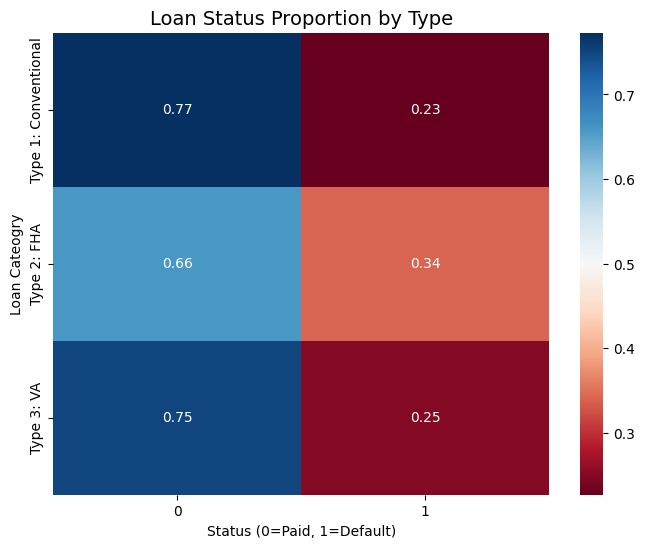

In [ ]:
# Pivot the grouped data so that:
# - Rows represent each loan_type
# - Columns represent each status category (e.g., 1= Default, 0= Non-Default /Paid)
# - Values represent the proportion (%) of each status within each loan_type

grouped_pivot=df_group.pivot(index='loan_type', columns='status', values='proportion')
grouped_pivot.index=['Type 1: Conventional', 'Type 2: FHA', 'Type 3: VA']
plt.figure(figsize=(8,6))
sns.heatmap(grouped_pivot, annot=True,cmap='RdBu')
#plt.pcolor(grouped_pivot, cmap='RdBu')
plt.title("Loan Status Proportion by Type", fontsize=14)
plt.ylabel("Loan Cateogry")
plt.xlabel("Status (0=Paid, 1=Default)")
plt.show()


#df_group= df.groupby(['region'], ['status'], as_index=False)

In [ ]:
# Calculate Pearson correlation and p‑value between loan amount and income

pearson_coef,p_value=stats.pearsonr(df['loan_amount'], df['income'])
pearson_coef

np.float64(0.44194511998099645)

In [ ]:
# By time trends
df.groupby('month',as_index=False)['loan_amount'].sum()
#df.groupby('year')['status'].mean()

,month,loan_amount
0,1,2902673000
1,2,2889665000
2,3,4263377000
3,4,4696433000
4,5,4776667500
5,6,4831256000
6,7,4302235500
7,8,4316679500
8,9,4291234000
9,10,3824607000


/tmp/ipykernel_3047/2817464708.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=df, x='loan_purpose', y='status',palette='viridis')
/tmp/ipykernel_3047/2817464708.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Purchase', 'Refinance', 'Home Improvement', 'Education'])


[Text(0, 0, 'Purchase'),
 Text(1, 0, 'Refinance'),
 Text(2, 0, 'Home Improvement'),
 Text(3, 0, 'Education')]

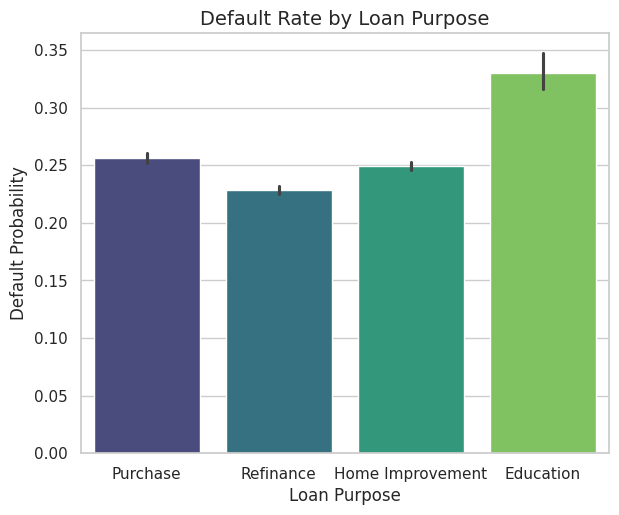

In [ ]:
# 1. Bar Chart — Default Rate by Loan Purpose

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15,12))

plt.subplot(2,2,1)
ax=sns.barplot(data=df, x='loan_purpose', y='status',palette='viridis')
plt.title('Default Rate by Loan Purpose', fontsize=14)
plt.ylabel('Default Probability')
plt.xlabel('Loan Purpose')
ax.set_xticklabels(['Purchase', 'Refinance', 'Home Improvement', 'Education'])

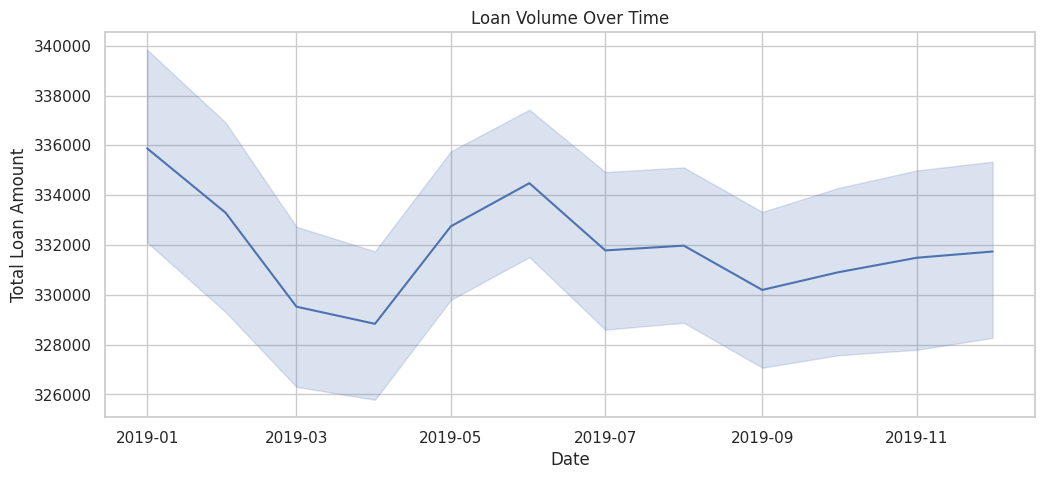

In [ ]:
# 2. Line Chart — Loan Trend Over Time
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='date_of_the_loan', y='loan_amount')
plt.title("Loan Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Total Loan Amount")
plt.show()

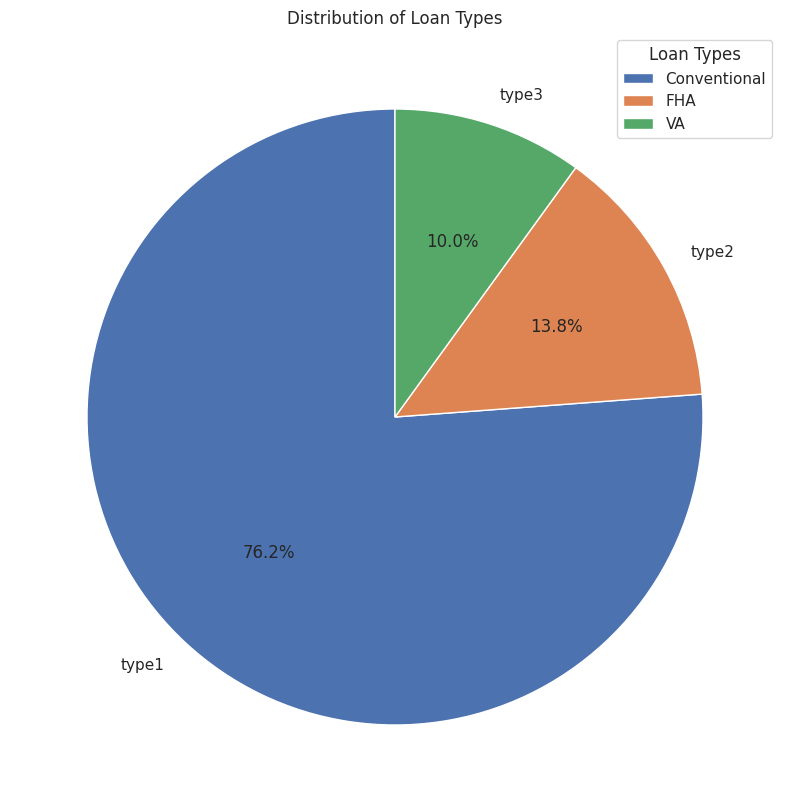

In [ ]:
#3. Pie Chart — Loan Distribution by Status
plt.figure(figsize=(10,10))
ax=df['loan_type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90)
plt.legend(labels=['Conventional', 'FHA','VA'],loc="best", title="Loan Types")
plt.title("Distribution of Loan Types")
plt.ylabel("")
plt.show()
#add legends type 1,2,3 meanings

/tmp/ipykernel_3047/1254985836.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(data=df, x='loan_purpose', y='dtir1', palette='Set2')
/tmp/ipykernel_3047/1254985836.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Purchase', 'Refinance', 'Home Improvement', 'Education'])


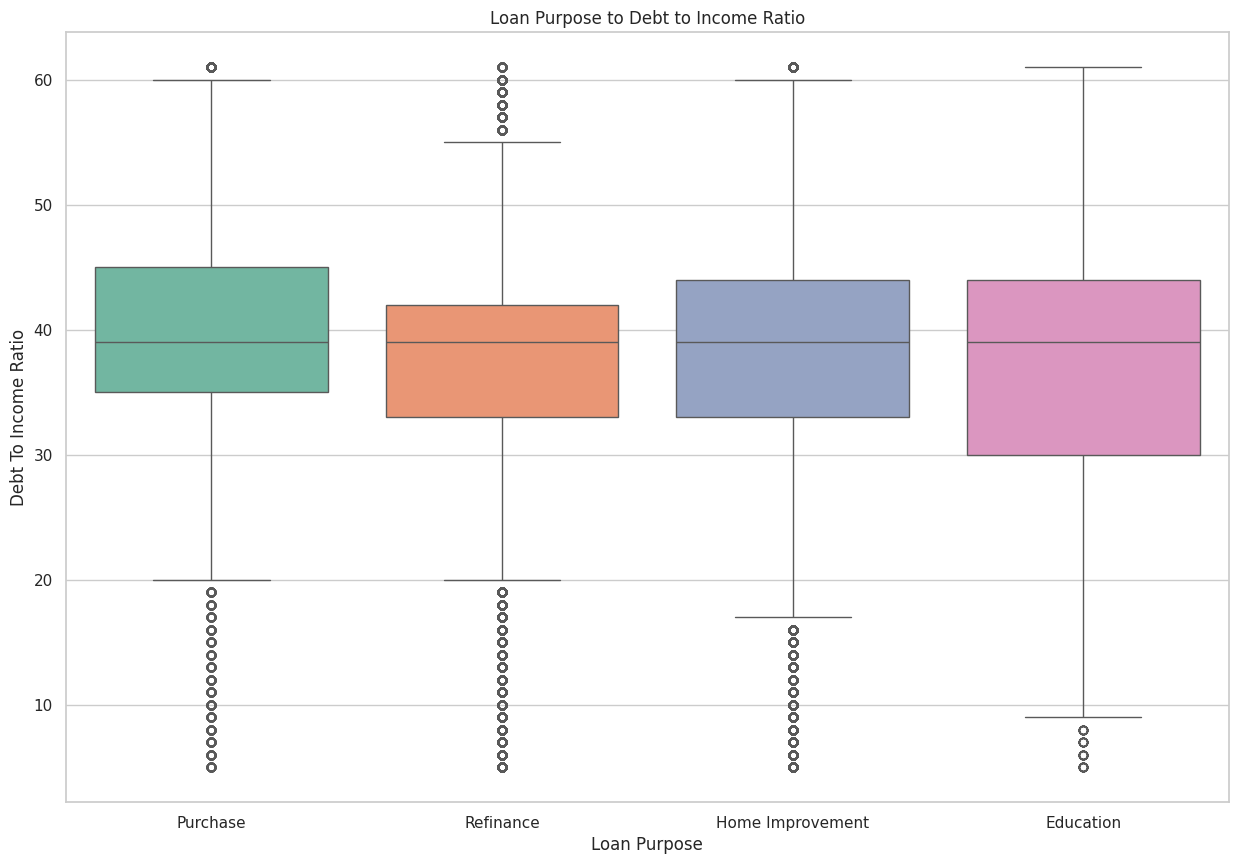

In [ ]:
#4. Box Plot — Loan Amount Spread (Outliers)
plt.figure(figsize=(15,10))
ax=sns.boxplot(data=df, x='loan_purpose', y='dtir1', palette='Set2')
plt.title("Loan Purpose to Debt to Income Ratio")
plt.xlabel('Loan Purpose')
plt.ylabel('Debt To Income Ratio')
ax.set_xticklabels(['Purchase', 'Refinance', 'Home Improvement', 'Education'])
plt.show()

In [ ]:
#----------------FOR         FROILA--------------
#sns.boxplot(y='property_value', data=df)
#sns.boxplot(y='credit_score', data=df) #WORKS!!!
#sns.boxplot(y='income', data=df)
#sns.boxplot(y='rate_of_interest', data=df) #WORKS!!!
#sns.boxplot(y='interest_rate_spread', data=df) #WORKS!!!
#sns.boxplot(y='dtir1', data=df) #WORKS!!!
#######sns.boxplot(y='loan_purpose', data=df) #WORKS

Compute correlation matrix for numeric columns and sort correlations with income

In [ ]:
#Compute correlation matrix for numeric columns
df.corr(numeric_only=True)

,id,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,ltv,status,dtir1,month,quarter
id,1.000000,-0.000459,0.000301,0.001642,-0.005224,-0.003901,0.000021,0.001573,-0.000513,-0.005082,0.001484,-0.007151,0.002964,0.002366
loan_amount,-0.000459,1.000000,-0.124083,-0.309674,0.057311,0.174589,0.685558,0.441945,0.004683,0.036108,-0.034686,0.014644,-0.002181,-0.002281
rate_of_interest,0.000301,-0.124083,1.000000,0.616585,-0.069616,0.181743,-0.104424,-0.015872,-0.000855,-0.001851,-0.043715,0.031280,0.000085,0.000157
interest_rate_spread,0.001642,-0.309674,0.616585,1.000000,0.036632,-0.137492,-0.286994,-0.100756,-0.001870,0.036246,-0.046264,0.049914,0.004330,0.004333
upfront_charges,-0.005224,0.057311,-0.069616,0.036632,1.000000,-0.046575,0.049753,0.026611,-0.001273,-0.031927,-0.094736,-0.013643,-0.004898,-0.004777
term,-0.003901,0.174589,0.181743,-0.137492,-0.046575,1.000000,0.042155,-0.057837,-0.002552,0.100362,-0.000662,0.106942,-0.005058,-0.005129
property_value,0.000021,0.685558,-0.104424,-0.286994,0.049753,0.042155,1.000000,0.389507,0.002581,-0.213621,-0.079112,-0.059838,-0.002085,-0.002820
income,0.001573,0.441945,-0.015872,-0.100756,0.026611,-0.057837,0.389507,1.000000,0.001590,-0.033925,-0.059832,-0.254796,-0.000043,-0.001440
credit_score,-0.000513,0.004683,-0.000855,-0.001870,-0.001273,-0.002552,0.002581,0.001590,1.000000,-0.005490,0.003173,-0.000182,0.000338,0.001338
ltv,-0.005082,0.036108,-0.001851,0.036246,-0.031927,0.100362,-0.213621,-0.033925,-0.005490,1.000000,0.041862,0.075160,-0.001916,-0.002165


In [ ]:
#Sort correlations with income
corr= df.select_dtypes(include=[np.number])
corr.corr()['income'].sort_values()

,income
dtir1,-0.254796
interest_rate_spread,-0.100756
status,-0.059832
term,-0.057837
ltv,-0.033925
rate_of_interest,-0.015872
quarter,-0.001440
month,-0.000043
id,0.001573
credit_score,0.001590


LOAN_AMOUNT  : PROPERTY_VALUE
LOAN_AMOUNT : INCOME
LOAN_AMOUNT : INTEREST_RATE_SPREAD [NEGATIVE CORR]
RATE_OF_INTEREST : interest_rate_spread
interest_rate_Spread: property_value
interst_rate_spread : loan_amount [neg corr]
dtir1 : income
ltv : property_value





<Axes: xlabel='property_value', ylabel='loan_amount'>

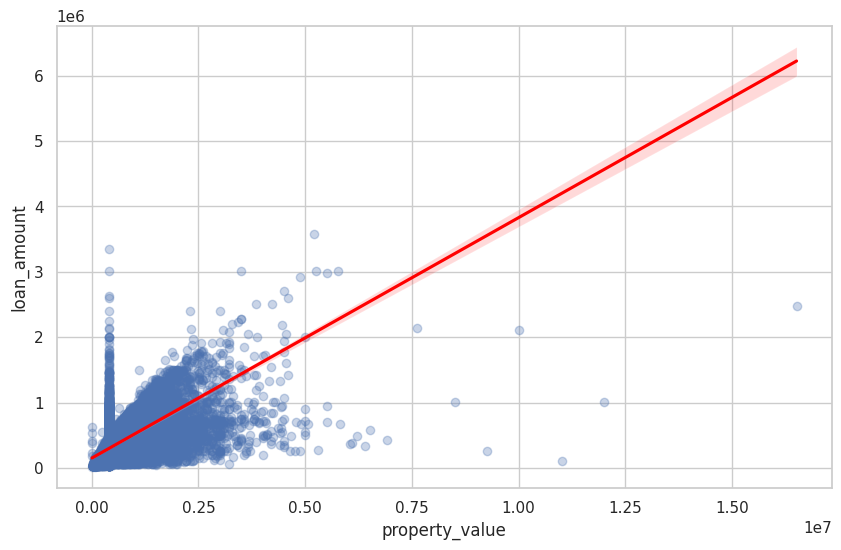

In [ ]:
# Correlation between property value and loan amount
corr=df[['property_value', 'loan_amount']].corr()
corr
plt.figure(figsize=(10,6))
sns.regplot(x='property_value', y='loan_amount', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

<Axes: xlabel='income', ylabel='loan_amount'>

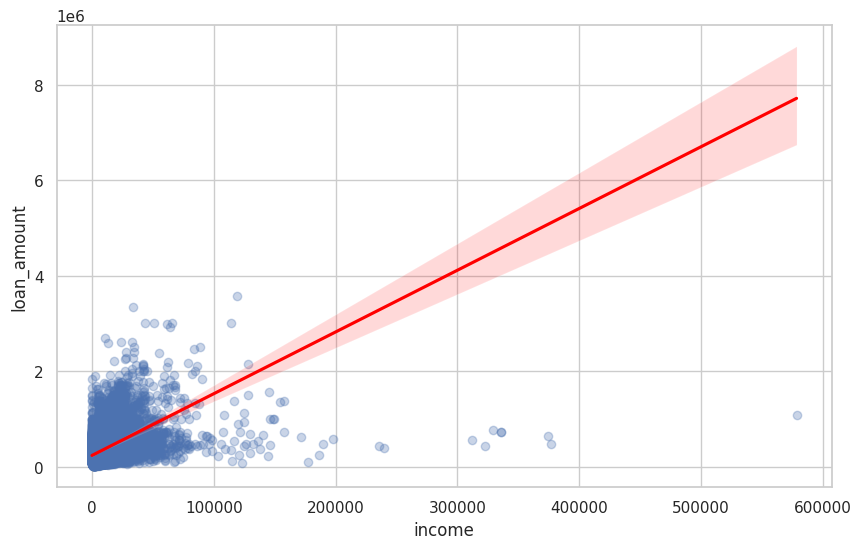

In [ ]:
# Regression plot to visualize the relationship between income and loan amount
plt.figure(figsize=(10,6))
sns.regplot(data=df, x='income', y='loan_amount',scatter_kws={'alpha':0.3},line_kws={'color':'red'})

<Axes: xlabel='loan_amount', ylabel='interest_rate_spread'>

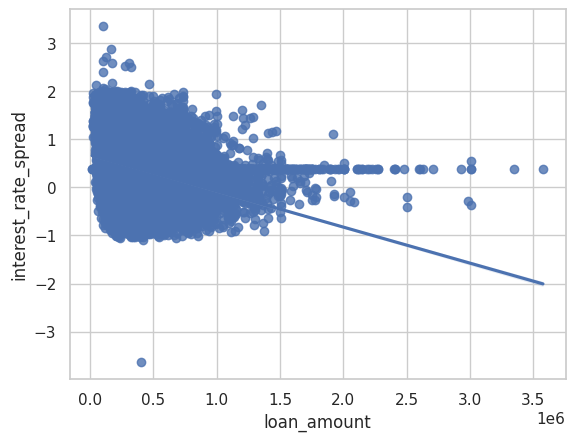

In [ ]:
# Regression plot to visualize the relationship between loan amount and interest rate spread
sns.regplot(data=df, x='loan_amount', y='interest_rate_spread')


<Axes: xlabel='property_value', ylabel='interest_rate_spread'>

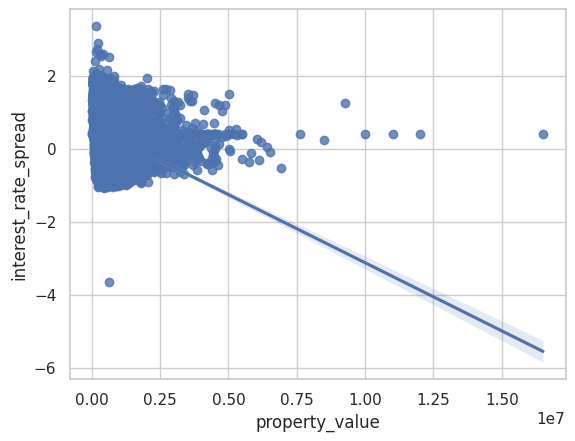

In [ ]:
# Regression plot to visualize the relationship between property value and interest rate spread
sns.regplot(data=df,x='property_value',y='interest_rate_spread')

We can Fit a linear regression model using the Loan Amount feature

<code>'loan_amount'</code> and  caculate the R^2.

In [ ]:
X = df[['income']]
Y = df['loan_amount']
lm = LinearRegression()
lm.fit(X,Y)
lm.score(X, Y)

0.1953154890750176

Fit a linear egression model to predict the Loan Amount

1.   Let's find the R2 first and tuple for model constructor
2.  Using the tuple created, we will create a pipeline object to predict 'Loan_Amount"



In [ ]:
features=["income", "credit_score","status", "rate_of_interest", "ltv", "dtir1" ]
lm2=LinearRegression()
lm2.fit(df[features], df['loan_amount'])
print(lm2.score(df[features], df['loan_amount']))

0.2296019573960163


In [ ]:
Input=[('scale',StandardScaler()),('polynomial', PolynomialFeatures(include_bias=False)),('model',LinearRegression())]
pipe=Pipeline(Input)
pipe.fit(df[features], df['loan_amount'])
print(pipe.score(df[features],df['loan_amount']))

0.3531793062992208


**CONCLUSION: THE PREDICTED MODEL IS A BETTER FIT**

**MODEL EVALUATION AND REFINEMENT**

In [ ]:
features=["income", "credit_score","status", "rate_of_interest", "ltv", "dtir1" ]
X = df[features]
Y = df['loan_amount']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)


print("number of test samples:", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples: 21598
number of training samples: 122385


Now we will create and fit a Ridge regression object using the training data, set the regularization parameter to 0.1, and calculate the R^2 using the test data.

In [ ]:
Ridge_model= Ridge(alpha=0.1)
Ridge_model.fit(x_train, y_train)
print(Ridge_model.score(x_test, y_test))

0.22648296176269067


Now we will perform a second order polynomial transform on both the training data and testing data. Creating and fit a Ridge regression object using the training data, set the regularisation parameter to 0.1, and calculate the R^2

In [ ]:
pr=PolynomialFeatures(degree=2)
x_train_pr= pr.fit_transform(x_train)
x_test_pr= pr.fit_transform(x_test)
Ridge_model1=Ridge(alpha=0.1)
Ridge_model1.fit(x_train_pr, y_train)
print(Ridge_model1.score(x_test_pr, y_test))

0.3284475726042131


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.6937e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


**QUESTION**: **HOW MANY DEFAULTS DO WE SEE EVERY MONTH?**

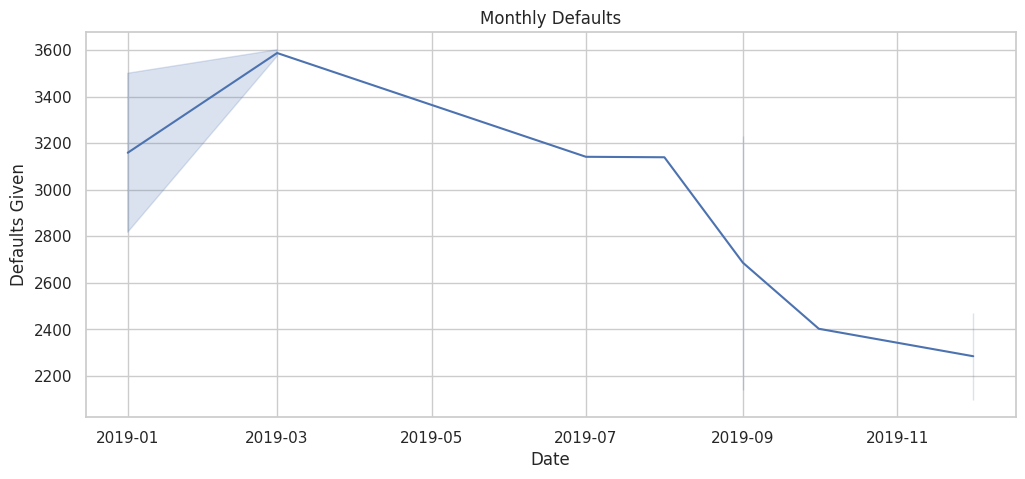

In [ ]:
monthly_defaults= df[df['status']==1].groupby('month').size()
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='date_of_the_loan', y=monthly_defaults)
plt.title("Monthly Defaults")
plt.xlabel("Date")
plt.ylabel("Defaults Given")
plt.show()

**QUESTION: Whether government backed loans were easily approved compared to non-governement?**

In [ ]:
#sns.boxplot(y='credit_score',x='loan_type', data=df)
#|'usless because all the values for all types is same
analysis = df.groupby('loan_type').agg({
    'credit_score':'mean',
    'status':'mean',
    'loan_amount':'median'
})
print(analysis)

           credit_score    status  loan_amount
loan_type                                     
type1        699.940772  0.227068     316500.0
type2        699.227768  0.340547     226500.0
type3        698.443440  0.249061     296500.0


In [ ]:
#Calculating the percentage of pre-approvals for each loan type
#This shows: Out of all Type 1 loans, what % got the 'pre' vs 'nopre'
pre_app_check= pd.crosstab(df['loan_type'], df['approv_in_adv'], normalize='index')*100

#Renaming types for clarity
pre_app_check.index=['Type1(Conventional)', 'Type 2(FHA)', 'Type 3(VA)']
print("Pre-Approval Rates by Loan Type (%):")
print(pre_app_check)

Pre-Approval Rates by Loan Type (%):
approv_in_adv            nopre        pre
Type1(Conventional)  84.101227  15.898773
Type 2(FHA)          82.952548  17.047452
Type 3(VA)           85.320718  14.679282


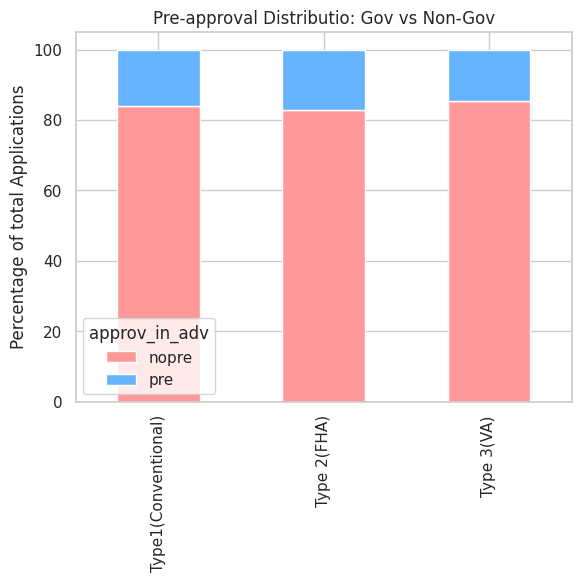

In [ ]:
pre_app_check.plot(kind='bar', stacked=True,color=['#ff9999','#66b3ff'])
plt.title("Pre-approval Distributio: Gov vs Non-Gov")
plt.ylabel("Percentage of total Applications")
plt.show()

INSIGHTS: Like we see the Type 2: FHA has a higher pre-approval rate compared to other types, it also had a higher default rate (mean of 0.33).
So, while the government-backed loans are 'easier' to approve (higher pre-approval rates), they carry significantly higher risk. The data shows a direct trade-off: the ease of approval in FHA loans correlates with a default rate that is roughly 10% higher than stricter Conventional loans

**QUESTION: The loan default times per credit score, how does credit score affects getting a loan for residence, and commercial.**

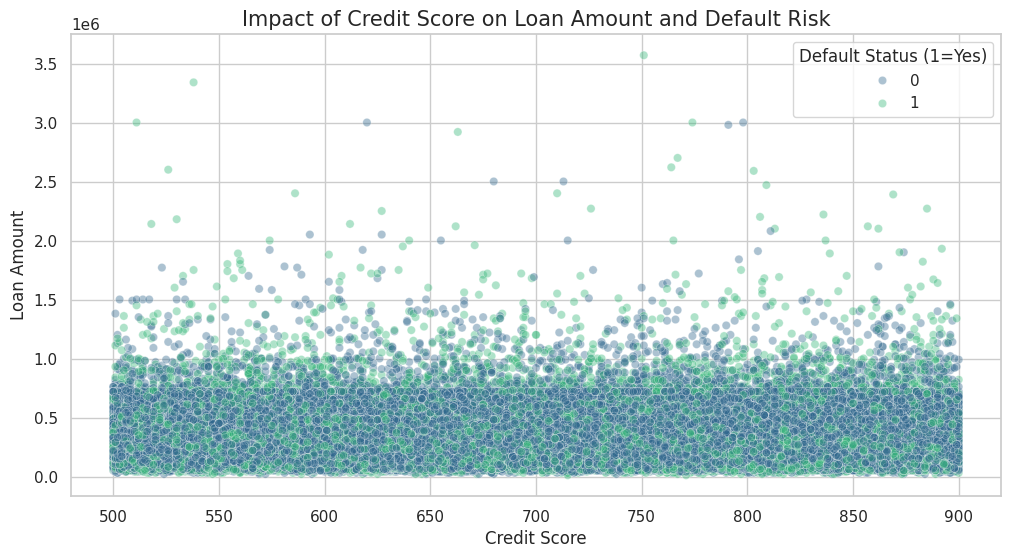

In [ ]:
plt.figure(figsize=(12,6))
#PLotting Credit Score vs Loan Amount, colored by Status (Default vs No Defualt)
sns.scatterplot(data=df, x='credit_score', y='loan_amount',hue='status', alpha=0.4, palette='viridis')

plt.title("Impact of Credit Score on Loan Amount and Default Risk", fontsize=15)
plt.xlabel("Credit Score")
plt.ylabel("Loan Amount")
plt.legend(title="Default Status (1=Yes)")
plt.show()

In [ ]:
# Comparing Credit Score and Default Rate by Property Usage
usage_comparison = df.groupby('business_or_commercial').agg({
    'credit_score': ['mean', 'min', 'max', 'std'],
    'status': 'mean'
})

print("Residential vs. Commercial Comparison:")
print(usage_comparison)

Residential vs. Commercial Comparison:
                       credit_score                          status
                               mean  min  max         std      mean
business_or_commercial                                             
b/c                      699.227768  500  900  116.497616  0.340547
nob/c                    699.767297  500  900  115.793695  0.229616


Even though the Credit Score range may be same for residential and commercial loans, the defualt rate for Business or commercial is higher compared to residential.
This inidicates that Business stability is a bigger risk factor than the individual's credit score in this category.

/tmp/ipykernel_3047/750286464.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='business_or_commercial', y='credit_score', palette='Set1')


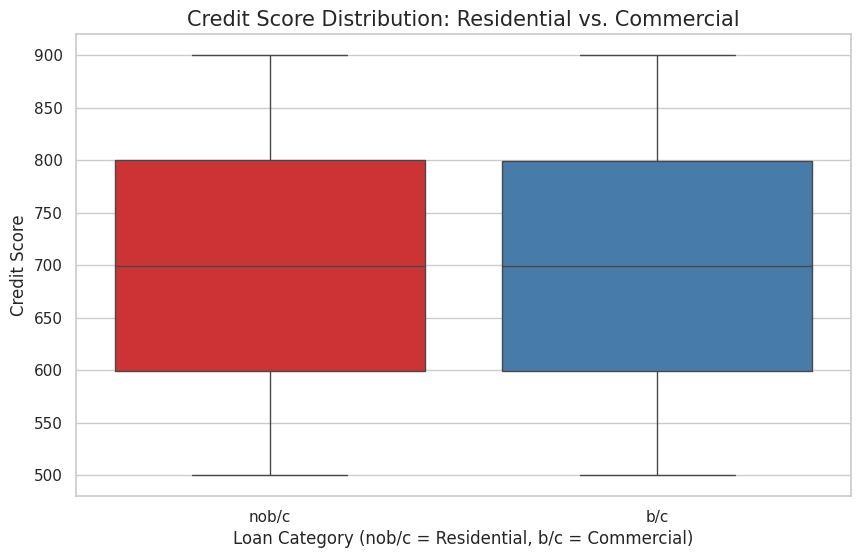

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='business_or_commercial', y='credit_score', palette='Set1')

plt.title("Credit Score Distribution: Residential vs. Commercial", fontsize=15)
plt.xlabel("Loan Category (nob/c = Residential, b/c = Commercial)")
plt.ylabel("Credit Score")
plt.show()

**CONCUSION: Credit score does not affect getting a residential or commercial loan.**

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Convert 'approv_in_adv' to 1s and 0s
df['pre_app_binary'] = df['approv_in_adv'].map({'pre': 1, 'nopre': 0})

# 2. Select your Features (X) and Target (y)
# Let's see if Credit Score and Income predict Pre-approval
X = df[['credit_score', 'income']]
y = df['pre_app_binary']

# 3. Fit the Logistic Model
log_model = LogisticRegression()
log_model.fit(X, y)

# 4. Check the accuracy
print(f"Model Accuracy: {log_model.score(X, y):.2%}")

Model Accuracy: 84.06%
